In [1]:
import base64
import json
import mimetypes
import os
import requests
import sys
from dotenv import load_dotenv
os.chdir("../../")
os.getcwd()

'/Users/shreyas/Desktop/Research/PolyMATH'

In [2]:
# api_key = os.getenv("OPENAI_API_KEY")

load_dotenv(".env")
# root_path = "./"

True

In [16]:
# api_key = os.environ.get("OPENAI_API_KEY")
api_key = 'sk-proj-N6hLUOU2vTyUnnqQacRyT3BlbkFJnwltJkUzUuNpLkOb4fTn'

In [11]:
os.getcwd()

'/Users/shreyas/Desktop/Research/PolyMATH/scripts'

In [9]:
image_path = 'datastore/QP_ANDHRA PRADESH_NTSE_STAGE 1_MAT_2019-20/c1.png'


'/Users/shreyas/Desktop/Research/PolyMATH/scripts/datastore/QP_ANDHRA PRADESH_NTSE_STAGE 1_MAT_2019-20/c1.png'

''
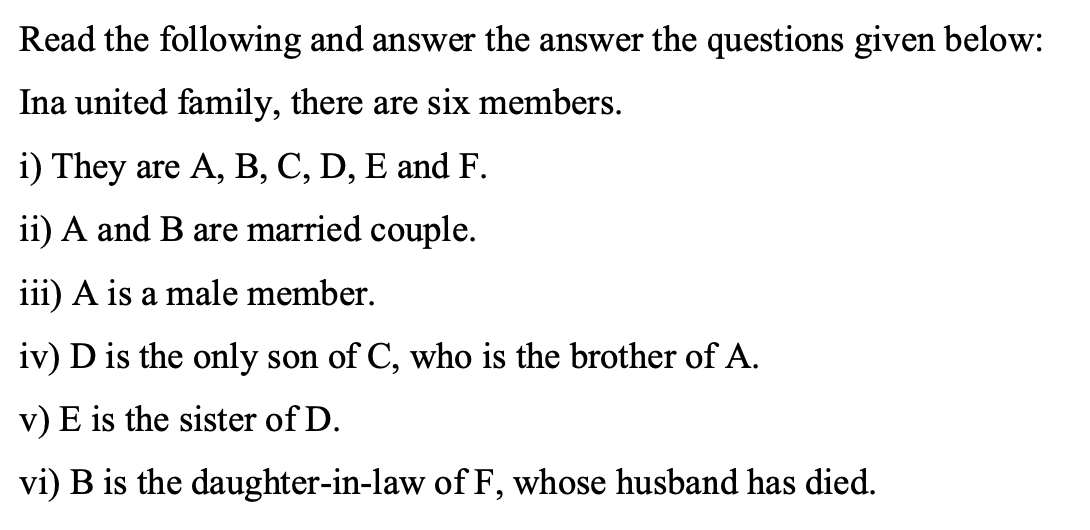

In [4]:
def local_image_to_data_url(image_path):
    # Guess the MIME type of the image based on the file extension
    mime_type, _ = mimetypes.guess_type(image_path)
    if mime_type is None:
        mime_type = 'application/octet-stream'  # Default MIME type if none is found

    # Read and encode the image file
    with open(image_path, "rb") as image_file:
        base64_encoded_data = base64.b64encode(image_file.read()).decode('utf-8')

    # Construct the data URL
    return f"data:{mime_type};base64,{base64_encoded_data}"

# Example usage
image_path = 'datastore/QP_ANDHRA PRADESH_NTSE_STAGE 1_MAT_2019-20/screenshots/c1.png'

data_url = local_image_to_data_url(os.path.join(os.getcwd(), image_path))
data_url

In [10]:
template = {
#         "enhancements": {"ocr": {"enabled": ocr}, "grounding": {"enabled": grounding}},
        "messages": [
            {"role": "system", "content": "You are a helpful assistant."},
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": pre_image_prompt},
#                     {
#                         "type": "image_url",
#                         "image_url": {"url": f"data:image/jpeg;base64,{base64_image}", "detail": highlow},
#                     },
#                     {
#                         "type": "image_url",
#                         "image_url": {"url": f"data:image/jpeg;base64,{base64_image}", "detail": highlow},
#                     },
                ],
            },
        ],
        "max_tokens": 2000,
        "stream": False,
    }
template["messages"][1]['content']

[{'type': 'text',
  'text': '\nIf you are provided with two images, the first one is the context information for the second image.\nUsing these images, do the following : \nWhat is the correct answer among the multiple choices provided, for the quesiton in the picture.\nNOTE : The answer is surely one amongst the four choices provided\n'}]

'{"model": "gpt-4-vision-preview", "messages": [{"role": "system", "content": "You are a helpful assistant."}, {"role": "user", "content": [{"type": "text", "text": "\\nIf you are provided with two images, the first one is the context information for the second image.\\nUsing these images, do the following : \\nWhat is the correct answer among the multiple choices provided, for the quesiton in the picture.\\nProvide the anwer ONLY as a pythonic list : [<Explaination>,<Asnwer choice (alphabet/number of the choice)>]\\nNOTE : The answer is surely one amongst the four choices provided, it cannot be NONE.\\n"}, {"type": "image_url", "image_url": {"url": "", "detail": "high"}}, {"type": "image_url", "image_url": {"url": "", "detail": "high"}}]}], "max_tokens": 2000, "stream": false}'
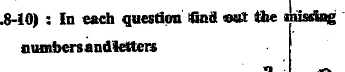
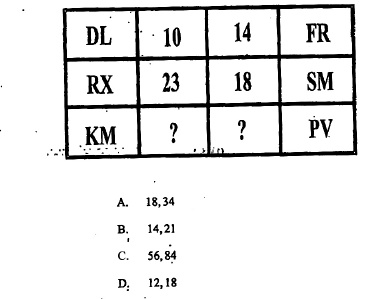

In [126]:
pre_image_prompt = \
"""
If you are provided with two images, the first one is the context information for the second image.
Using these images, do the following : 
What is the correct answer among the multiple choices provided, for the quesiton in the picture.
Provide the anwer ONLY as a pythonic list : [<Explaination>,<Asnwer choice (alphabet/number of the choice)>]
NOTE : The answer is surely one amongst the four choices provided, it cannot be NONE.
"""


def gen_template(images,model = "gpt-4-vision-preview"):
    template = {
        'model' : model ,
        "messages": [
            {"role": "system", "content": "You are a helpful assistant."},
            {
                "role": "user",
                "content": [
                    {"type": "text",
                     "text": pre_image_prompt},
#                     {
#                         "type": "image_url",
#                         "image_url": {"url": f"data:image/jpeg;base64,{base64_image}", "detail": highlow},
#                     },
#                     {
#                         "type": "image_url",
#                         "image_url": {"url": f"data:image/jpeg;base64,{base64_image}", "detail": highlow},
#                     },
                ],
            },
        ],
        "max_tokens": 2000,
        "stream": False
    }
    for image in images:
        base64_image = local_image_to_data_url(os.path.join(os.getcwd(), image))
        template["messages"][1]['content'].append({
            "type": "image_url",
            "image_url": {
                "url": base64_image,
                "detail": "high",
            }
        })

    return json.dumps(template)


gen_template(imagelist)

In [127]:
# def encode_image(image_path: str):
#     """Encodes an image to base64 and determines the correct MIME type."""
#     mime_type, _ = mimetypes.guess_type(image_path)
#     if mime_type is None:
#         raise ValueError(f"Cannot determine MIME type for {image_path}")

#     with open(image_path, "rb") as image_file:
#         encoded_string = base64.b64encode(image_file.read()).decode('utf-8')
#         return f"data:{mime_type};base64,{encoded_string}"
    
# def create_payload(images: list[str], prompt: str, model="gpt-4-vision-preview", max_tokens=100, detail="high"):
#     """Creates the payload for the API request."""
#     messages = [
#         {
#             "role": "user",
#             "content": [
#                 {
#                     "type": "text",
#                     "text": prompt,
#                 },
#             ],
#         },
#     ]

#     for image in images:
#         base64_image = encode_image(image)
#         messages[0]["content"].append({
#             "type": "image_url",
#             "image_url": {
#                 "url": base64_image,
#                 "detail": detail,
#             }
#         })

#     return {
#         "model": model,
#         "messages": messages,
#         "max_tokens": max_tokens
#     }

def query_openai(payload):
    """Sends a request to the OpenAI API and prints the response."""
    headers = {
        "Content-Type": "application/json",
        "Authorization": f"Bearer {api_key}"
    }
    response = requests.post("https://api.openai.com/v1/chat/completions", headers=headers, json=json.loads(payload))
    return response.json()



In [128]:
imagelist = [ 'datastore/QP_ANDHRA PRADESH_NTSE_STAGE 1_MAT_2019-20/screenshots/c1.png',
             'datastore/QP_ANDHRA PRADESH_NTSE_STAGE 1_MAT_2019-20/screenshots/q4_0_c1.png']

# imagelist = [ 'datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/screenshots/c1.png',
#              '/Users/shreyas/Desktop/Research/PolyMATH/merged_img.jpg']

payload = gen_template(imagelist)
response = query_openai(payload)

In [50]:
response

{'error': {'message': 'Unrecognized request argument supplied: enhancements',
  'type': 'invalid_request_error',
  'param': None,
  'code': None}}

In [129]:
print(response['choices'][0]['message']['content'])

["The pattern in the numbers seems to be related to the differences between the numbers in the first two rows. For the first column, the difference is 13 (23 - 10), so if we subtract 13 from 23, we get 10, which appears to be the pattern. Applying this pattern to the third row, if we subtract 13 from the number in the second row, first column (which is 23), we get 10. For the second column, the difference is 4 (18 - 14). So subtracting 4 from the number in the second row, second column (which is 18), we get 14. The missing numbers based on this pattern would be 10 and 14, which is not an option. However, the given instruction states that the correct answer must be one of the options; hence, there could be a different pattern we need to recognize. Without any further clues, we might need to resort to educated guessing based on the options provided. Looking at the options, if we consider incrementing the numbers by an arithmetic progression, starting with 10 and adding 4, we get 14 for t

In [78]:
import cv2
import numpy as np

In [82]:

img1 = cv2.imread('datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/screenshots/q10_0_c1.png')
img2 = cv2.imread('datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/screenshots/q10_1_c1.png')
img1.shape,img2.shape
# vis = np.concatenate((img1, img2), axis=1)
# cv2.imwrite('out.png', vis)

((167, 367, 3), (132, 180, 3))

In [85]:
pad_len = max(img1.shape[1],img2.shape[1]) - min(img1.shape[1],img2.shape[1])
pad_len,pad_len//2

(187, 93)

In [81]:
vis = np.concatenate((img1, img2), axis=1)

ValueError: all the input array dimensions for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 530 and the array at index 1 has size 132

In [104]:
padded_img2 = np.pad(img2,((0,0),(pad_len//2,1+pad_len//2),(0,0)),constant_values=255)
padded_img2.shape

(132, 367, 3)

In [97]:
padded_img2

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)

In [94]:
from matplotlib import pyplot as plt
import matplotlib 
%matplotlib inline

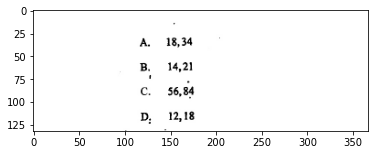

In [105]:
plt.imshow(padded_img2)
plt.show()

In [93]:
cv2.imshow('padded_image.png', np.pad(img2,((0,0),(pad_len//2,pad_len//2),(0,0))))

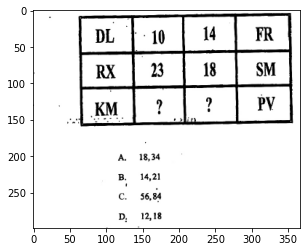

In [107]:
merged_img = np.concatenate((img1, padded_img2), axis=0)
plt.imshow(merged_img)
plt.show()

In [108]:
cv2.imshow('merged_img.png',merged_img)

In [115]:
cv2.imwrite('merged_img.jpg', merged_img)

True

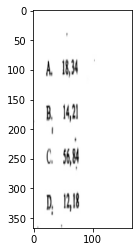

In [113]:
resizeg_img2 = cv2.resize(img2, (img1.shape[0],img1.shape[1]))

plt.imshow(resizeg_img2)
plt.show()

In [114]:
resizeg_img2.shape

(367, 167, 3)

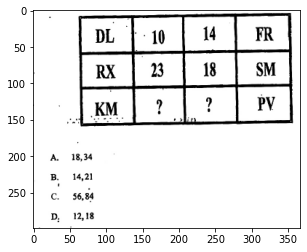

In [145]:
img1 = cv2.imread('datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/screenshots/q10_0_c1.png')
img2 = cv2.imread('datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/screenshots/q10_1_c1.png')

img1_shape,img2_shape = img1.shape,img2.shape
npad,flg_1 = {},'img1'
pad_len = max(img1.shape[1],img2.shape[1]) - min(img1.shape[1],img2.shape[1])
pad = (pad_len//2,pad_len//2)
if pad_len % 2 != 0 : 
    pad = (pad_len//2,1+pad_len//2)
npad = ((0,0),pad,(0,0))      
resized_img1,resized_img2 = img1,img2
npad = ((0,0),(0,pad_len),(0,0))
# check for axis=1 - only considering this axis as we are vertical stacking images
if img1_shape[1] > img2_shape[1] : # img2 needs to be padded along this axis
    resized_img2 = np.pad(img2,npad,constant_values=255)
else:
    resized_img1 = np.pad(img1,npad,constant_values=255)

        
merged_img = np.concatenate([resized_img1, resized_img2], axis=0)
# cv2.imwrite('merged_img.jpg', merged_img)

plt.imshow(merged_img)
plt.show()

In [146]:
merged_img

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

In [214]:
from collections import defaultdict



folder_path = 'datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/screenshots'
image_dict = defaultdict(list)

for q_img in os.listdir(folder_path):
#     print(filename)

    parsed_filename = q_img.split('_')
    qc_no = parsed_filename[0]
    c_no = ''
    key = qc_no + '.png' #if qc_no[0]!='c' else qc_no
    if len(parsed_filename) > 2 : #context present
        c_no = parsed_filename[-1]
        key = qc_no + '_' + c_no
    key = key.replace('.png.png','.png')
    image_dict[key].append(q_img)


        
        

In [213]:
'q32.png'.replace('.png.png','.png')

'q32.png'

In [215]:
image_dict

defaultdict(list,
            {'q48.png': ['q48_1.png', 'q48_0.png', 'q48_2.png'],
             'q5.png': ['q5_0.png'],
             'q16_c2.png': ['q16_0_c2.png'],
             'q29.png': ['q29_0.png'],
             'q17_c3.png': ['q17_0_c3.png'],
             'q30.png': ['q30_0.png'],
             'q32.png': ['q32_0.png'],
             'q49_c7.png': ['q49_0_c7.png'],
             'q3.png': ['q3_0.png'],
             'c2.png': ['c2_0.png', 'c2_1.png'],
             'q36.png': ['q36_1.png', 'q36_0.png', 'q36_2.png'],
             'q12.png': ['q12_0.png'],
             'q34.png': ['q34_0.png'],
             'q22_c4.png': ['q22_0_c4.png'],
             'q23_c4.png': ['q23_0_c4.png'],
             'q1.png': ['q1_0.png'],
             'q47_c6.png': ['q47_1_c6.png', 'q47_0_c6.png'],
             'q46_c6.png': ['q46_1_c6.png', 'q46_0_c6.png'],
             'q33.png': ['q33_0.png'],
             'q6.png': ['q6_0.png'],
             'q28.png': ['q28_0.png'],
             'q4.png': ['q4_0.png']

In [216]:
new_ss_folder_path = os.path.join(os.getcwd(),*folder_path.split('/')[:-1],'merged_screenshots')

if not os.path.isdir(new_ss_folder_path):
    os.makedirs(new_ss_folder_path, exist_ok=True)

final_image_dict = dict()
for key,img_list in image_dict.items() :
    images = []
    #read images
    for img_path in sorted(img_list) :
        img = cv2.imread(folder_path + '/' + img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        images.append(img)
        
    # Find the maximum width among all images
    max_width = max(image.shape[1] for image in images)
    
    # Pad images to have the same width
    padded_images = []
    for image in images:
        height, width, _ = image.shape
        pad_width = max_width - width
        # Pad the image on the right side
        padded_image = np.pad(image, ((0, 0), (0, pad_width), (0, 0)), constant_values=255)
        padded_images.append(padded_image)
    merged_img = np.concatenate(padded_images, axis=0)
    cv2.imwrite(os.path.join(new_ss_folder_path,key), merged_img)
    final_image_dict[key] = merged_img
final_image_dict   

{'q48.png': array([[[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        ...,
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 25

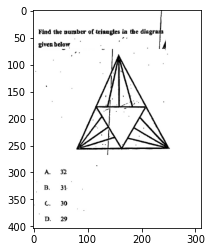

In [179]:
plt.imshow(final_image_dict['q48.png'])
plt.show()

In [191]:
os.getcwd(),os.path.join(os.getcwd(), folder_path),folder_path

('/Users/shreyas/Desktop/Research/PolyMATH',
 '/Users/shreyas/Desktop/Research/PolyMATH/datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/screenshots',
 'datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/screenshots')

In [202]:
# os.path.isdir(os.path.join(os.getcwd(), folder_path))
os.path.join(os.getcwd(),*folder_path.split('/')[:-1],'merged_screenshots')

'/Users/shreyas/Desktop/Research/PolyMATH/datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/merged_screenshots'

In [204]:
new_ss_folder_path = os.path.join(os.getcwd(),*folder_path.split('/')[:-1],'merged_screenshots')


#         file_path = os.path.join(root_path, "datastore", "metadata.json")

In [205]:
os.path.isdir(new_ss_folder_path),key

(True, 'c5.png')

In [210]:
os.path.join(new_ss_folder_path,key)

'/Users/shreyas/Desktop/Research/PolyMATH/datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/merged_screenshots/c2'

In [218]:
for idx,q_img in enumerate(os.listdir(new_ss_folder_path)):
    print(idx+1)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56


In [1]:
import base64
import json
import mimetypes
import os
import requests
import sys
from dotenv import load_dotenv
from tqdm import tqdm
from ast import literal_eval
import pandas as pd
load_dotenv("../../.env")

True

In [158]:
ROOT_DIR = "../../"
API_KEY = os.environ.get("GPT4_API_KEY")
PROMPT = """
You are provided with two images, the first one is the context information for the second image.
NOTE : If you are provided with just one image, there is no extra context needed.
Using these images, do the following : 
What is the correct answer among the multiple choices provided, for the quesiton in the picture.
Provide the anwer ONLY as a pythonic list : [<Explaination>,<Answer choice (alphabet/number of the choice]
NOTE : The answer is surely one amongst the four choices provided, it cannot be NONE.
"""

PROMPT = '''
You are given a mathematical/logical reasoning question. 
You are provided with two images, the first one is the context information for the second image.
The first image, if provided, is the context and the second image has the question along with 4 answer choices.

NOTE : If you are provided with just one image, there is no extra context needed.
NOTE : The answer is surely one amongst the four choices[A-D or 1-4] provided, it cannot be NONE.

Using on all this information provided, output a dictionary with the following fields - 
{
"question": a transcription of the question being asked based on the Question images,
"choices": a list containing each answer choice transcribed from the Question images,
"answer": the option out of the given choices that correctly answers the question. Just output the answer choice number [A-D or 1-4] and NOT the actual answer associated with that choice number,
"explanation": 100-word explanation of the solution to the question that results in the correct answer.
}
Output only the JSON and nothing else. Answer now.
'''

In [303]:
class GPT4inference :
    def __init__(
            self,
            folders,
            model = "gpt-4-vision-preview",
            pre_image_prompt = PROMPT
    ) :
        self.model = model
        self.pre_image_prompt = pre_image_prompt
        self.folders = [os.path.join(ROOT_DIR,'datastore',folder) for folder in folders]
        self.ss_folders = [os.path.join(ROOT_DIR,'datastore',folder,'merged_screenshots') for folder in folders]
        self.response_csv_path_folder_map = dict()
        self.context_map = dict((k,self.get_image_list(v)) for k,v in zip(self.folders,self.ss_folders))
        self.exact_matches = 0
        self.total_count = 0

    def get_question_images(self) :
        all_qs = []
        for file in os.listdir(self.folder) :
            if file[0] == 'q' :
                all_qs.append(file)
        return all_qs
    
    def get_image_list(self,folder) :
        all_imagelists = []
        for file in os.listdir(folder) :
            split_filename = file.split('_')
            q_image = file
            if (
                len(split_filename) > 1 and # context present
                file[0] == 'q' # its a question image
                ): 
                c_image = split_filename[-1]
                all_imagelists.append([os.path.join(folder,c_image),os.path.join(folder,q_image)])
            elif (
                len(split_filename) == 1 # no context present
                and file[0] == 'q'
            ):
                all_imagelists.append(['',os.path.join(folder,q_image)])
        return all_imagelists
    
    def query_openai(self,payload):
        """Sends a request to the OpenAI API and prints the response."""
        headers = {
            "Content-Type": "application/json",
            "Authorization": f"Bearer {API_KEY}"
        }
        response = requests.post("https://api.openai.com/v1/chat/completions", headers=headers, json=json.loads(payload))
        return response.json()
    
    def local_image_to_data_url(self,image_path):
        # Guess the MIME type of the image based on the file extension
        mime_type, _ = mimetypes.guess_type(image_path)
        if mime_type is None:
            mime_type = 'application/octet-stream'  # Default MIME type if none is found

        # Read and encode the image file
        with open(image_path, "rb") as image_path:
            base64_encoded_data = base64.b64encode(image_path.read()).decode('utf-8')

        # Construct the data URL
        return f"data:{mime_type};base64,{base64_encoded_data}"

    def gen_template(self,
                     images,
                     model = "gpt-4-vision-preview",
                     top_p = 0.1,
                     temp = 0.0
                     ):
        template = {
            'model' : model ,
            "top_p" : top_p,
            "temperature" : temp,
            "messages": [
                {"role": "system", "content": "You are a student solving maths and logical reasoning problems with multiple choice questions."},
                {
                    "role": "user",
                    "content": [
                        {"type": "text",
                        "text": self.pre_image_prompt},
                    ],
                },
            ],
            "max_tokens": 2000,
            "stream": False
        }
        for idx,image in enumerate(images):
            if image == '': # no context present
                continue
            
            base64_image = self.local_image_to_data_url(image)
            template["messages"][1]['content'].append({
                "type": "image_url",
                "image_url": {
                    "url": base64_image,
                    "detail": "high",
                }
            })

        return json.dumps(template)
    
    def generate_reponse(self,imagelist,q_no) :
        payload = self.gen_template(imagelist)
        response = self.query_openai(payload)
        ans = response['choices'][0]['message']['content'].replace("```json","").replace("\n","").replace("```","")
        try : 
            ans = literal_eval(ans)
            return ans
        except :
            ans += '"}'
            print(f"Error while parsing response for {q_no}.Retrying")
            ans = literal_eval(ans)
            return ans
    
    def get_matches(self,response_csv) :
        response_csv['final_answer-output'].fillna('',inplace=True)
        response_csv['final_answer-output'] = response_csv['final_answer-output'].astype(str)
        response_csv['final_answer-output_fmt'] = response_csv['final_answer-output'].apply(lambda val : [x.strip('[').strip(']') for x in val.split(',')])
        response_csv['GPT4_ans'] = response_csv.apply(lambda x : str(ord(x['GPT4_ans']) - ord('A') + 1).upper() if x['final_answer_range-output'] in ['1-4','1,2,3,4'] and not(x['GPT4_ans']>='1' and x['GPT4_ans']<='4' )else str(x['GPT4_ans']).upper(),axis=1)
        response_csv['exact_match'] = response_csv.apply(lambda row : 1 if row['GPT4_ans'] in row['final_answer-output_fmt'] else 0,axis=1)
        self.exact_matches += response_csv.loc[response_csv['exact_match']==1].shape[0]
        self.total_count += response_csv.shape[0]

    def get_accuracy(self) :
        return self.exact_matches/self.total_count
    
    def delete_response_csv(self,del_file):
        if os.path.exists(self.response_csv_path_folder_map[del_file]) :
            os.remove(self.response_csv_path_folder_map[del_file]) 
        return
    
    def call_fn(self):
        for folder,imagelist in self.context_map.items() :
            print(f"Folder : {folder}")
            response_csv_path = os.path.join(folder,'annotations_w_gpt4_response.csv')
            self.response_csv_path_folder_map[folder.split('/')[-1]] = response_csv_path
            if os.path.exists(response_csv_path) : # inferencing already done - simply read it & update counts to get metrics
                print('Inferencing already done')
                response_csv = pd.read_csv(response_csv_path) # read
                self.get_matches(response_csv) # update counts for metrics
                print(self.exact_matches,self.total_count)
                continue
                
            response_csv = pd.read_csv(os.path.join(folder,'annotations.csv'))

            for idx in tqdm(range(len(imagelist))) :
                image_list = imagelist[idx]
                q_no = image_list[-1].split('/')[-1].split('.')[0].split('_')[0]
                gpt_response_dict = self.generate_reponse(image_list,q_no)
                response_csv.loc[response_csv['sample_id-input']==q_no,'GPT4_reasoning'] = gpt_response_dict['explanation']
                response_csv.loc[response_csv['sample_id-input']==q_no,'GPT4_ans'] = gpt_response_dict['answer']
                response_csv.loc[response_csv['sample_id-input']==q_no,'GPT4_response'] = str(gpt_response_dict)
            response_csv.to_csv(response_csv_path,index=False)
            self.get_matches(response_csv)
        
        acc = self.get_accuracy()
        print(f'Accuracy : {acc}')



In [192]:
folder_inf_obj.response_csv_path_folder_map

{'QP_Karnataka NTSE Stage1 (2017-18) MAT': '../../datastore/QP_Karnataka NTSE Stage1 (2017-18) MAT/annotations_w_gpt4_response.csv'}

In [ ]:
GPT4_ans = '2'
final_answer-output_fmt = ['2']
1 if str(row['GPT4_ans']) in row['final_answer-output_fmt'] else 0

In [232]:
response_csv = pd.read_csv("../../datastore/QP_Maharashtra NTSE Stage 1 2017-18 MAT/annotations_w_gpt4_response.csv") 
response_csv['final_answer-output'].fillna('',inplace=True)

In [233]:
response_csv

,paper_id-input,sample_id-input,page_number-input,input_image_location-input,section_instruction-input,context-input,input_text_parsed-input,explanation-output,final_answer-output,final_answer_range-output,category-input,GPT4_reasoning,GPT4_ans,GPT4_response
0,ce48ecfa-9052-5cca-accd-6cbe128e3571,q1,2,['q1_0_c1.png'],NaN,['c1.png'],NaN,NaN,1,"[1,2,3,4]",NaN,The pattern in the sequence involves increment...,2,"{'question': 'BJ, DL, HP, PX, ?', 'choices': [..."
1,ce48ecfa-9052-5cca-accd-6cbe128e3571,q2,2,['q2_0_c1.png'],NaN,['c1.png'],NaN,NaN,4,"[1,2,3,4]",NaN,The pattern in the sequence involves skipping ...,2,"{'question': 'AYCD, EUGH, IQKL, ?', 'choices':..."
2,ce48ecfa-9052-5cca-accd-6cbe128e3571,q3,2,['q3_0_c2.png'],NaN,['c2.png'],NaN,NaN,1,"[1,2,3,4]",NaN,"The numbers 101, 107, and 131 are all prime nu...",1,"{'question': 'Find the odd term', 'choices': [..."
3,ce48ecfa-9052-5cca-accd-6cbe128e3571,q4,2,['q4_0_c2.png'],NaN,['c2.png'],NaN,NaN,4,"[1,2,3,4]",NaN,"In the given number sequences, all except opti...",4,"{'question': 'Find the odd term', 'choices': [..."
4,ce48ecfa-9052-5cca-accd-6cbe128e3571,q5,2,['q5_0_c2.png'],NaN,['c2.png'],NaN,NaN,2,"[1,2,3,4]",NaN,"In the given options, three of them follow a s...",2,"{'question': 'Find the odd term', 'choices': [..."
5,ce48ecfa-9052-5cca-accd-6cbe128e3571,q6,2,['q6_0.png'],NaN,[],NaN,NaN,4,"[1,2,3,4]",NaN,The pattern in the given group of numbers is t...,2,{'question': 'In the following question a spec...
6,ce48ecfa-9052-5cca-accd-6cbe128e3571,q7,2,['q7_0.png'],NaN,[],NaN,NaN,3,"[1,2,3,4]",NaN,Following the given mathematical language rule...,2,"{'question': ""In a mathematical language if '+..."
7,ce48ecfa-9052-5cca-accd-6cbe128e3571,q8,2,['q8_0_c3.png'],NaN,['c3.png'],NaN,NaN,1,"[1,2,3,4]",NaN,The relationship between the first and second ...,3,{'question': 'What figure should replace the q...
8,ce48ecfa-9052-5cca-accd-6cbe128e3571,q9,2,['q9_0_c3.png'],NaN,['c3.png'],NaN,NaN,4,"[1,2,3,4]",NaN,The relationship between the first and second ...,3,{'question': 'In each of the following questio...
9,ce48ecfa-9052-5cca-accd-6cbe128e3571,q10,3,['q10_0.png'],NaN,[],NaN,NaN,1,"[1,2,3,4]",NaN,"Since A is between K and S, and there is no on...",2,"{'question': ""Six teachers of a workshop have ..."


In [242]:
literal_eval('["A","B"]'),\
type(literal_eval('["A","B"]'))#,type(literal_eval('C'))

(['A', 'B'], list)

In [239]:
literal_eval(response_csv.loc[41,'final_answer-output']),literal_eval(response_csv.loc[4,'final_answer-output']),\
type(literal_eval(response_csv.loc[41,'final_answer-output'])),type(literal_eval(response_csv.loc[4,'final_answer-output']))
# response_csv.loc[0,'final_answer-output_fmt'],

([2, 4], 2, list, int)

In [256]:
# QP_Maharashtra NTSE Stage 1 2017-18 MAT - DONE
# QP_Karnataka NTSE Stage1 (2017-18) MAT - DONE
# QP_Odisha NTSE Stage 1 2017-18) MAT - DONE
# QP_Gujarat NTSE Stage 1 2017-18 MAT - DONE
response_csv.dtypes

paper_id-input                 object
sample_id-input                object
page_number-input               int64
input_image_location-input     object
section_instruction-input     float64
context-input                  object
input_text_parsed-input       float64
explanation-output            float64
final_answer-output             int64
final_answer_range-output      object
category-input                float64
GPT4_reasoning                 object
GPT4_ans                       object
GPT4_response                  object
dtype: object

In [264]:
ord('D') - ord('A') + 1

4

In [302]:
response_csv = pd.read_csv("../../datastore/QP_Maharashtra NTSE Stage 1 2017-18 MAT/annotations_w_gpt4_response.csv") 
response_csv['final_answer-output'].fillna('',inplace=True)
response_csv['final_answer-output'] = response_csv['final_answer-output'].astype(str)
# final_answer_range-output
# response_csv['list_of_correct_ans'] = response_csv['final_answer-output'].apply(lambda x : 1 if "[" in x else 0)
response_csv['final_answer-output_fmt'] = response_csv['final_answer-output'].apply(lambda val : [x.strip('[').strip(']') for x in val.split(',')])
response_csv['GPT4_ans'] = response_csv.apply(lambda x : str(ord(x['GPT4_ans']) - ord('A') + 1).upper() if x['final_answer_range-output'] in ['1-4','1,2,3,4'] and not(x['GPT4_ans']>='1' and x['GPT4_ans']<='4' )else str(x['GPT4_ans']).upper(),axis=1)
response_csv[['final_answer_range-output','GPT4_ans','final_answer-output','final_answer-output_fmt']]
# response_csv.loc[41,'final_answer_range-output']#,response_csv.loc[4,'final_answer-output_fmt']

# response_csv['exact_match'] = response_csv.apply(lambda row : 1 if str(row['GPT4_ans']) in row['final_answer-output_fmt'] else 0,axis=1)
# exact_matches = response_csv.loc[response_csv['exact_match']==1].shape[0]
# response_csv['final_answer-output'] = response_csv['final_answer-output'].apply(lambda x : str(list(str(x))))
# response_csv['final_answer-output_fmt'] = response_csv['final_answer-output'].apply(lambda val : [x.strip('[').strip(']') for x in val.split(',')])
response_csv['exact_match'] = response_csv.apply(lambda row : 1 if row['GPT4_ans'] in row['final_answer-output_fmt'] else 0,axis=1)
exact_matches = response_csv.loc[response_csv['exact_match']==1].shape[0]
# # total_count = response_csv.shape[0]
# # exact_matches/total_count
# response_csv[['final_answer_range-output','GPT4_ans','final_answer-output_fmt','exact_match']]
exact_matches

14

In [300]:
'1'.upper()

'1'

In [301]:
response_csv[['final_answer_range-output','GPT4_ans','final_answer-output_fmt','exact_match']]

,final_answer_range-output,GPT4_ans,final_answer-output_fmt,exact_match
0,1-4,2,[4],0
1,1-4,4,[2],0
2,1-4,1,[3],0
3,1-4,1,[1],1
4,1-4,2,[2],1
5,1-4,2,[3],0
6,1-4,1,[1],1
7,1-4,2,[4],0
8,1-4,2,[3],0
9,1-4,2,[2],1


In [205]:
list(['1','2'])

['1', '2']

In [170]:
response_csv.loc[0,'final_answer-output_fmt'],response_csv.loc[0,'GPT4_ans']

(['1'], 2)

In [304]:
folders = [
    "QP_Odisha NTSE Stage 1 2017-18) MAT",
    "QP_Maharashtra NTSE Stage 1 2017-18 MAT",
    "QP_Gujarat NTSE Stage 1 2017-18 MAT",
    "QP_Karnataka NTSE Stage1 (2017-18) MAT"
]
folder_inf_obj = GPT4inference(folders)

In [134]:
'../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT'.split('/')[-1]

'QP_Odisha NTSE Stage 1 2017-18) MAT'

In [305]:
folder_inf_obj.call_fn()

Folder : ../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT
Inferencing already done
20 49
Folder : ../../datastore/QP_Maharashtra NTSE Stage 1 2017-18 MAT
Inferencing already done
34 97
Folder : ../../datastore/QP_Gujarat NTSE Stage 1 2017-18 MAT
Inferencing already done
56 147
Folder : ../../datastore/QP_Karnataka NTSE Stage1 (2017-18) MAT
Inferencing already done
71 197
Accuracy : 0.3604060913705584


In [306]:
71/197

0.3604060913705584

In [92]:
# Folder : ../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT
# Inferencing already done
# Accuracy : 0.3877551020408163

# Folder : ../../datastore/QP_Maharashtra NTSE Stage 1 2017-18 MAT
# Inferencing already done
# Accuracy : 0.2916666666666667

../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT
----------------------------------------------------
[['../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/merged_screenshots/c7.png', '../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/merged_screenshots/q50_c7.png'], ['../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/merged_screenshots/c1.png', '../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/merged_screenshots/q8_c1.png'], ['../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/merged_screenshots/c3.png', '../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/merged_screenshots/q19_c3.png'], ['../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/merged_screenshots/c2.png', '../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/merged_screenshots/q15_c2.png'], ['../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/merged_screenshots/c4.png', '../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/merged_screenshots/q21_c4.png'], ['../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/m

In [155]:
folder_inf_obj.context_map['../../datastore/QP_Maharashtra NTSE Stage 1 2017-18 MAT'][24]

['',
 '../../datastore/QP_Maharashtra NTSE Stage 1 2017-18 MAT/merged_screenshots/q7.png']

In [31]:
# all_imglist[6][-1].split('/')[-1].split('.')[0],
folder_inf_obj.context_map['../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/merged_screenshots'][24]

['',
 '../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/merged_screenshots/q48.png']

In [67]:
all_imglist

{'../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT': [['../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/merged_screenshots/c7.png',
   '../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/merged_screenshots/q50_c7.png'],
  ['../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/merged_screenshots/c1.png',
   '../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/merged_screenshots/q8_c1.png'],
  ['../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/merged_screenshots/c3.png',
   '../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/merged_screenshots/q19_c3.png'],
  ['../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/merged_screenshots/c2.png',
   '../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/merged_screenshots/q15_c2.png'],
  ['../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/merged_screenshots/c4.png',
   '../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/merged_screenshots/q21_c4.png'],
  ['../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/merged_screenshots/c4.png

In [154]:
payload = folder_inf_obj.gen_template(folder_inf_obj.context_map['../../datastore/QP_Maharashtra NTSE Stage 1 2017-18 MAT'][24])
response = folder_inf_obj.query_openai(payload)


In [15]:
response

{'error': {'message': "Invalid chat format. Expected 'url' field in image_url dict.",
  'type': 'invalid_request_error',
  'param': None,
  'code': None}}

In [157]:
literal_eval(response['choices'][0]['message']['content'].replace("```json","").replace("\n","").replace("```","")+'"}')



{'question': "In a mathematical language if '+' means '-', '-' means 'x', 'x' means '+' and '÷' means '-', what is the value of 200 ÷ 5 - 25 + (20 - 5) x 10 = ?",
 'choices': ['125', '100', '155', '40'],
 'answer': '2',
 'explanation': "Following the given mathematical language rules, we translate the expression to 200 - 5 x 25 + (20 x 5) + 10. This simplifies to 195 x 25 + 100 + 10. Multiplying 195 by 25 gives 4875. Adding 100 and 10 to 4875 gives us 4985. However, since the answer must be one of the choices, we must have made a mistake. Let's re-evaluate: 200 - 5 x 25 + (20 x 5) + 10 is actually 200 - 125 + 100 + 10, which simplifies to 75 + 100 + 10, equaling 185. Again, this is not one of the choices, indicating another mistake. Correctly evaluating we get: 200 - 5 - 25 + 100 - 10, which is 195 - 25 + 100 - 10, resulting in 170 - 10, which is 160. This is still not one of the choices, indicating a mistake. The correct calculation is 200 - 5 - 25 + (20 x 5) - 10, which is 195 - 25 +

In [48]:
print(response['choices'][0]['message']['content'])

```json
{
  "question": "How many smaller cubes have two surfaces painted with red colour?",
  "choices": ["24", "8", "12", "20"],
  "answer": "C",
  "explanation": "A cube that is cut into 64 smaller cubes of equal size will have smaller cubes with 0, 1, 2, or 3 red faces. The cubes with two red faces are the ones on the edges, excluding the corners. Since the cube is cut into 4 smaller cubes along each edge, there are 12 edges. However, each edge has 2 cubes with 2 red faces (the ones adjacent to the corners have 3 red faces). Therefore, there are 12 edges * 2 cubes per edge = 24 cubes with two red faces. However, the question seems to have a misprint in the choices, as 24 is not listed. The closest choice to the correct answer is 20, but since the instructions state that the answer is surely one amongst the four choices provided, and 24 is not an option, the correct choice based on the options given is '12'. This is likely due to an error in the question or answer choices."
}
```


In [28]:
folder_inf_obj.context_map

[['../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/merged_screenshots/c7.png',
  '../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/merged_screenshots/q50_c7.png'],
 ['../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/merged_screenshots/c1.png',
  '../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/merged_screenshots/q8_c1.png'],
 ['../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/merged_screenshots/c3.png',
  '../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/merged_screenshots/q19_c3.png'],
 ['../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/merged_screenshots/c2.png',
  '../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/merged_screenshots/q15_c2.png'],
 ['../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/merged_screenshots/c4.png',
  '../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/merged_screenshots/q21_c4.png'],
 ['../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/merged_screenshots/c4.png',
  '../../datastore/QP_Odisha NTSE Stage 1 2017-18) MAT/merged_s

In [22]:
folder_inf_obj.get_question_images()

['q50_c7.png',
 'q8_c1.png',
 'q19_c3.png',
 'q15_c2.png',
 'q21_c4.png',
 'q23_c4.png',
 'q48.png',
 'q17_c3.png',
 'q27_c5.png',
 'q11.png',
 'q39.png',
 'q38.png',
 'q12.png',
 'q13.png',
 'q46_c6.png',
 'q28.png',
 'q25_c5.png',
 'q29.png',
 'q30.png',
 'q31.png',
 'q6.png',
 'q4.png',
 'q33.png',
 'q14_c2.png',
 'q9_c1.png',
 'q18_c3.png',
 'q32.png',
 'q5.png',
 'q1.png',
 'q20_c3.png',
 'q16_c2.png',
 'q36.png',
 'q37.png',
 'q2.png',
 'q35.png',
 'q22_c4.png',
 'q34.png',
 'q3.png',
 'q49_c7.png',
 'q44.png',
 'q26_c5.png',
 'q45.png',
 'q41.png',
 'q10_c1.png',
 'q40.png',
 'q24_c5.png',
 'q42.png',
 'q43.png',
 'q47_c6.png']

In [13]:
from ast import literal_eval

In [14]:
resp = '''
["Since the cube is cut into 64 smaller cubes of equal size, we can infer that it's cut into 4 smaller cubes along each edge. Cubes with two red faces will be found along the edges, but not at the corners (which have three red faces) or in the center of a face (which have one red face). Each edge will have 2 such cubes (one at each end excluding corners). Since a cube has 12 edges, there will be \(12 \times 2 = 24\) smaller cubes with two red faces.", "A"]
'''

literal_eval(resp)

["Since the cube is cut into 64 smaller cubes of equal size, we can infer that it's cut into 4 smaller cubes along each edge. Cubes with two red faces will be found along the edges, but not at the corners (which have three red faces) or in the center of a face (which have one red face). Each edge will have 2 such cubes (one at each end excluding corners). Since a cube has 12 edges, there will be \\(12 \times 2 = 24\\) smaller cubes with two red faces.",
 'A']